Import Required Libraries

In [338]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

Data Collection and Processing

In [339]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('heart.csv')

In [340]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [341]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [342]:
# number of rows and columns in the dataset
heart_data.shape

(303, 14)

In [343]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [344]:
# checking for missing values
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [345]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [346]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

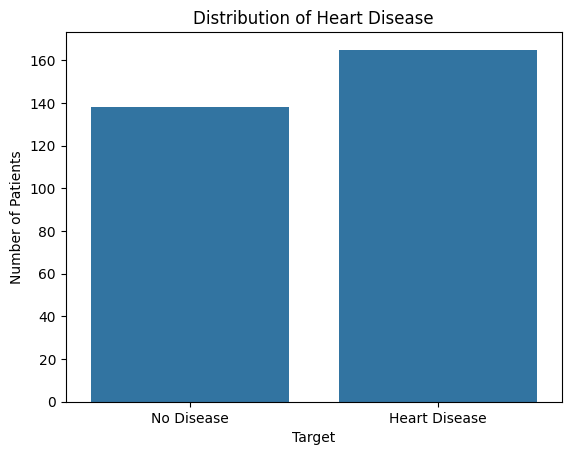

In [347]:
sns.countplot(x='target',data=heart_data)
plt.title("Distribution of Heart Disease")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Heart Disease"])

plt.show()

1 --> Heart Disease

0 --> No Heart Disease

Splitting the Features and Target

In [348]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [349]:
print(X.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  
0   0     1  
1   0     2  
2   0     2  
3   0     2  
4   0     2  


In [350]:
print(Y.head())

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


Splitting the Data into Training data & Test Data

In [351]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [352]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


Train the SVM Model

In [353]:
svm_model = SVC(probability=True, random_state=42)

In [354]:
svm_model.fit(X_train,Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Evaluate the SVM Model

In [355]:
svm_X_train_prediction = svm_model.predict(X_train)
svm_training_data_accuracy = accuracy_score(Y_train,svm_X_train_prediction)
print('Accuracy on Training data SVM: ', svm_training_data_accuracy)

Accuracy on Training data SVM:  0.6942148760330579


In [356]:
svm_test_prediction = svm_model.predict(X_test)

svm_test_accuracy = accuracy_score(Y_test, svm_test_prediction)

print("Accuracy on Test Data SVM:", svm_test_accuracy)

Accuracy on Test Data SVM: 0.6229508196721312


In [357]:
input_data = (
    62, 0, 0, 140, 268,
    0, 0, 160, 0,
    3.6, 0, 2, 2
)

input_data = np.asarray(input_data)

input_data_reshaped = input_data.reshape(1, -1)

In [358]:
svm_prediction = svm_model.predict(input_data_reshaped)
print("SVM Prediction:",svm_prediction[0])

if (svm_prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

SVM Prediction: 1
The Person has Heart Disease


c:\Users\TECH CLUB\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Train the Random Forest Model

In [359]:
rf_model = RandomForestClassifier(random_state=42)

In [360]:
rf_model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluate the Random Forest Model

In [361]:
rf_X_train_prediction = rf_model.predict(X_train)
rf_training_data_accuracy = accuracy_score(Y_train,rf_X_train_prediction)
print('Accuracy on Training data Random Forest : ', rf_training_data_accuracy)

Accuracy on Training data Random Forest :  1.0


In [362]:
rf_test_prediction = rf_model.predict(X_test)

rf_test_accuracy = accuracy_score(Y_test, rf_test_prediction)

print("Accuracy on Test Data Random Forest:", rf_test_accuracy)

Accuracy on Test Data Random Forest: 0.8032786885245902


In [363]:
rf_prediction = rf_model.predict(input_data_reshaped)
print("Random Forest Prediction:",rf_prediction[0])

if (rf_prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

Random Forest Prediction: 0
The Person does not have a Heart Disease


c:\Users\TECH CLUB\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Train the XGBoost Model

In [364]:
xgb_model = XGBClassifier(random_state=42)

In [365]:
xgb_model.fit(X_train,Y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


Evaluate the XGBoost Model

In [366]:
xgb_X_train_prediction = xgb_model.predict(X_train)
xgb_training_data_accuracy = accuracy_score(Y_train,xgb_X_train_prediction)
print('Accuracy on Training data XGBoost: ', xgb_training_data_accuracy)

Accuracy on Training data XGBoost:  1.0


In [367]:
xgb_test_prediction = xgb_model.predict(X_test)

xgb_test_accuracy = accuracy_score(Y_test, xgb_test_prediction)

print("Accuracy on Test Data XGBoost:", xgb_test_accuracy)

Accuracy on Test Data XGBoost: 0.7540983606557377


In [368]:
xgb_prediction = xgb_model.predict(input_data_reshaped)
print("XGBoost Prediction:",xgb_prediction[0])

if (xgb_prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

XGBoost Prediction: 0
The Person does not have a Heart Disease


Compare Model Performance

In [369]:


print("Accuracy on Test Data SVM:", svm_test_accuracy)

print("Accuracy on Test Data Random Forest:", rf_test_accuracy)

print("Accuracy on Test Data XGBoost:", xgb_test_accuracy)

Accuracy on Test Data SVM: 0.6229508196721312
Accuracy on Test Data Random Forest: 0.8032786885245902
Accuracy on Test Data XGBoost: 0.7540983606557377


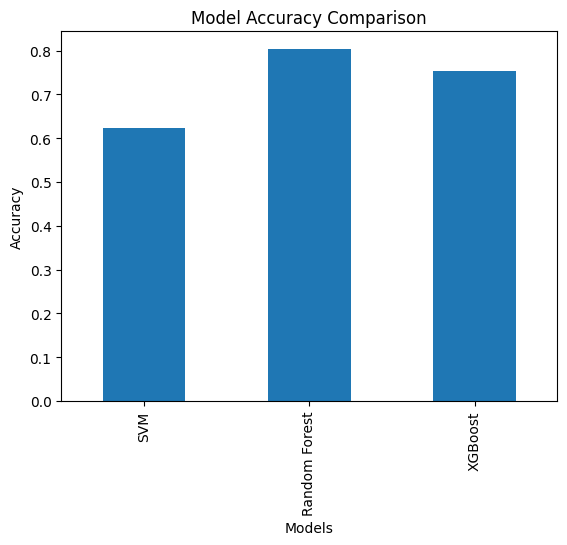

In [370]:
comparison = pd.DataFrame({
    "Model": ["SVM", "Random Forest", "XGBoost"],
    "Test Accuracy": [
        svm_test_accuracy,
        rf_test_accuracy,
        xgb_test_accuracy
    ]
})


comparison.plot(
    x="Model",
    y="Test Accuracy",
    kind="bar",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [371]:
print("SVM Prediction:", svm_prediction[0])
print("Random Forest Prediction:", rf_prediction[0])
print("XGBoost Prediction:", xgb_prediction[0])

SVM Prediction: 1
Random Forest Prediction: 0
XGBoost Prediction: 0
